# Implementing a Drive-Based Controller with Memory

We will build a simple controller with two drives: hunger and curiosity. At all times, the controller will have a goal location that it is travelling towards. 

When the agent is curious, it will choose a goal location it has not visited and move in that direction, recording everything it senses in its memory. When the agent is hungry, it will search its memory for a location containing food and set that as the goal.

First let's train a drive classifier to guide our search. Then we'll build up to an `AgentModel`. For this experiment, we'll use a Gaussian location model with position mean and standard deviation, as used in `SpatialMemory` (see [Developing Spatial Memory](map_testing.ipynb)).

In [1]:
from tree_world.simulation import TreeWorld, TreeWorldConfig
from tree_world.models.drives import train_drive_classifier

config = TreeWorldConfig()

# we only want to train on the tree names (e.g. mango, pear, etc.), not the ids (Bob, Alice, etc.)
drive_classifier, drive_keys = train_drive_classifier(config, with_ids=False)
inverse_drive_keys = {v: k for k, v in drive_keys.items()}


Drive Embedding Classifier Loss (with fruit amount): 0.3065146207809448 MSE: 1.6890255210455507e-05 Accuracy: 100.00%


## Supporting Classes for Locations and Drives

Our agent model needs two properties at all times:
- a goal location
- a current drive

When the drive changes, a new goal must be selected. Thus we will need functions
- `choose_hunger_goal()`
- `choose_curiosity_goal()`

We will also need to know when the agent has reached its goals.

For all of this, we will create helper classes to abstract locations and targets. These classes will help us to track and monitor the goals and progress towards the goal.

In [2]:
import torch


class Location:
    def __init__(self, location: torch.Tensor, location_sd: torch.Tensor):
        self.location = location
        self.location_sd = location_sd


class Target:
    arrive_z_threshold: float = 0.1

    def __init__(self, 
        start_location: Location, 
        target_location: Location
    ):
        self.start_location = start_location
        self.current_location = start_location
        self.target_location = target_location

        self.arrival_count = 0
        self.arrival_check_count = 0

    def update_current_location(self, location: Location):
        self.current_location = location

    def has_arrived(self) -> bool:
        z = self.current_location.location - self.target_location.location
        if self.target_location.location_sd is not None:
            sd = self.target_location.location_sd + self.current_location.location_sd
        else:
            sd = self.current_location.location_sd
        
        z = z / (sd + 1e-6)

        result = torch.norm(z) < self.arrive_z_threshold

        self.arrival_check_count = self.arrival_check_count + 1
        if result:
            self.arrival_count = self.arrival_count + 1

        return result
    
    def get_heading(self) -> torch.Tensor:
        direction = self.target_location.location - self.current_location.location
        return direction / torch.norm(direction)
        

class DriveTarget(Target):
    def __init__(self, 
        drive_embedding: torch.Tensor,
        sensory_target: torch.Tensor,
        start_location: Location, 
        target_location: Location,
    ):
        super().__init__(start_location, target_location)
        self.drive_embedding = drive_embedding
        self.sensory_target = sensory_target

We'll also implement a `DriveManager` to help us choose our goal locations and to assess whether a sensory input is positive (fruit) or negative (poison). 

`DriveManager.choose_hunger_target()` will sample for a target location matching the hunger drive near to the current location. These samples will be checked against the memory, and the "best" sample (highest hunger affinity) will be chosen as the target. If there is no match, it will return `None`.

In [3]:
from typing import Optional
import torch
from tree_world.models.drives import DriveEmbeddingClassifier
from tree_world.models.memory import SpatialMemory


class DriveManager:
    def __init__(self, drive_embedding_model: DriveEmbeddingClassifier, drive_keys: dict, memory: SpatialMemory):
        self.drive_embedding_model = drive_embedding_model
        self.drive_keys = drive_keys
        self.memory = memory
    
    def choose_hunger_target(
        self, 
        location: 'Location', 
        temperature: float=1.0, 
        sigma_scale: float=1.0, 
        num_samples: int=25,
        location_temperature: float=100.0,
        match_threshold: float=25,
        lower_match_threshold: float=5.0,
    ) -> Optional['DriveTarget']:
        hunger_idx = self.drive_keys["edible"]
        hunger_value = self.drive_embedding_model.drive_embeddings.weight[hunger_idx]

        location_mean, location_sd = self.memory.sample(
            location.location[None, :], 
            location.location_sd[None, :], 
            hunger_value[None, :], 
            return_distribution=True,
            temperature=temperature,
            num_samples=num_samples,
            sigma_scale=sigma_scale,
            location_temperature=location_temperature,
            match_threshold=None, # <-- the location_temperature will eliminate faraway locations
            lower_match_threshold=lower_match_threshold,
        )

        sensory_expectation = self.memory.read(location_mean, location_sd, match_threshold=match_threshold)  # (batch_size, num_samples, sensory_dim)
        hunger_score = torch.bmm(sensory_expectation, hunger_value[None, :, None]).squeeze(-1)  # (batch_size, num_samples)
        hunger_values, indices = torch.max(hunger_score, dim=-1)
        if hunger_values[0] > 0.0:
            location_indices = indices.unsqueeze(-1).repeat(1, 1, location_mean.shape[-1])
            location_mean = location_mean.gather(dim=-2, index=location_indices).squeeze(-2)  # (batch_size, sensory_dim)
            location_sd = location_sd.gather(dim=-2, index=location_indices).squeeze(-2)  # (batch_size, sensory_dim)

            sensory_indices = indices.unsqueeze(-1).repeat(1, 1, sensory_expectation.shape[-1])
            sensory_target = sensory_expectation.gather(dim=-2, index=sensory_indices).squeeze(-2)  # (batch_size, sensory_dim)

            target_location = Location(location_mean.squeeze(0), location_sd.squeeze(0))
            drive_target = DriveTarget(
                hunger_value,
                sensory_target,
                location,
                target_location,
            )
            return drive_target
        else:
            return None

    def choose_curiosity_target(self, location: 'Location', space_scale: float) -> Optional['DriveTarget']:
        # for now, choose a random location uniformly
        target_location_mean = torch.empty_like(location.location).uniform_(-space_scale, space_scale)
        target_location_sd = torch.ones_like(location.location_sd)
        target_location = Location(target_location_mean.squeeze(0), target_location_sd.squeeze(0))

        target = Target(location, target_location)
        return target

    def assess_valence(self, sensory: torch.Tensor) -> float:
        squeeze = False
        if sensory.ndim < 2:
            sensory = sensory[None, :]
            squeeze = True
        drive_targets = self.drive_embedding_model(sensory.detach())

        output = (
            drive_targets[:, self.drive_keys["edible"]] -
            drive_targets[:, self.drive_keys["poison"]]
        )

        if squeeze:
            return output[0].item()
        else:
            return output

Let's check that our drive manager works ok. We'll create a world, a sensor, and a memory and show some hunger targets and location targets.

In [4]:
from tree_world.simulation import TreeWorldConfig, TreeWorld, SimpleSensor

R = 50
D = 1024
S = 2 * R + 1
real_magnitude = 500.0

config = TreeWorldConfig()
config.embedding_dim = D
config.max_memory_size = S**2
sensor = SimpleSensor.from_config(config)
world = TreeWorld.random_from_config(config)

In [5]:
from tree_world.visualize import make_sensory_grid

grid_locations, sensor_values = make_sensory_grid(S, real_magnitude, world, sensor)

In [6]:
from tree_world.visualize import RGBProjector
rgb_model = RGBProjector.make_rgb_model_from_sensor_values(sensor_values)

memory.memory_locations: torch.Size([1, 10201, 2]) memory.memory_senses: torch.Size([1, 10201, 1024])
hunger_target: DriveTarget([-190.0, -220.0], [5.0, 5.0])


/Users/alockett/dev/tree-world/src/tree_world/visualize.py:269: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


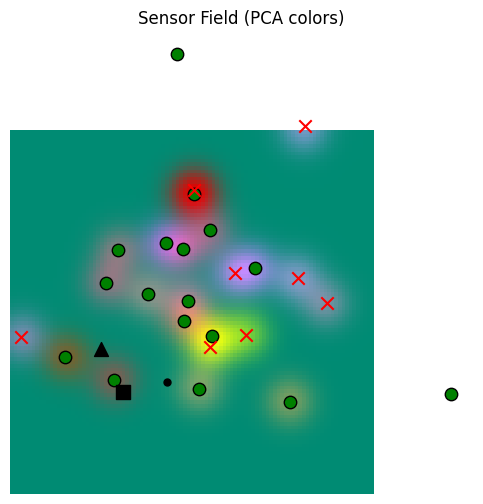

In [7]:
from tree_world.models.memory import SpatialMemory

memory = SpatialMemory.from_config(config)
drive_manager = DriveManager(drive_classifier, drive_keys, memory)
memory.write(grid_locations[None, ...], torch.full_like(grid_locations[None, ...], 5.0), sensor_values[None, ...])
memory_values = memory.read(grid_locations[None, ...], torch.full_like(grid_locations[None, ...], 5.0)).squeeze(0)

print(f"memory.memory_locations: {memory.memory_locations.shape} memory.memory_senses: {memory.memory_senses.shape}")

base_sensor_field, fig, ax = rgb_model.plot_sensor_field(world, memory_values)

agent_location = torch.tensor([-250.0, -100.0])
agent_location_sd = torch.ones(2) * 5.0

hunger_target = drive_manager.choose_hunger_target(
    Location(agent_location, agent_location_sd), 
    temperature=0.01, 
    sigma_scale=1.0, 
    num_samples=25,
    match_threshold=25,
    lower_match_threshold=5.0,
    location_temperature=10_000,
)
assert hunger_target is not None
print(f"hunger_target: {hunger_target.__class__.__name__}({hunger_target.target_location.location.squeeze(0).detach().cpu().numpy().tolist()}, {hunger_target.target_location.location_sd.squeeze(0).detach().cpu().numpy().tolist()})")

hunger_mean = hunger_target.target_location.location.squeeze(0)

ax.scatter(hunger_mean[0], hunger_mean[1], marker="s", color="black", s=100)
ax.scatter(agent_location[0], agent_location[1], marker="^", color="black", s=100)


curiosity_target = drive_manager.choose_curiosity_target(
    Location(agent_location, agent_location_sd), 
    space_scale=500.0,
)

curiosity_mean = curiosity_target.target_location.location.squeeze(0)

ax.scatter(curiosity_mean[0], curiosity_mean[1], marker=".", color="black", s=100)



So we can get decent samples of where to go for hunger from our fully populated memory, although we have to carefully set the temperature ($0.01$) and location weight ($0.0001$ -- balancing the location importance to sampling).

## Building the Agent Model: First Approach

The first version of our agent will do the following steps in order:
1. Update the current drive
2. Choose a new target if the drive changed OR if the target was reached
3. Compute an action to move towards the target.

In [51]:
from tree_world.simulation import AgentModel

class DriveBasedAgentWithMemory(AgentModel):
    action_scale: float = 1.0
    space_scale: float = 500.0
    hunger_threshold: float = 0.5
    
    def __init__(self, 
        sensory_embedding_dim: int, 
        sensory_embedding_model: str, 
        dim: int=2, 
        can_see_fruit_distance: float=10.0, 
        max_distance: float=100.0,
        memory: SpatialMemory=None,
        drive_manager: DriveManager=None,
    ):
        super().__init__(sensory_embedding_dim, sensory_embedding_model, dim, can_see_fruit_distance, max_distance)
        assert memory is not None
        assert drive_manager is not None

        self.memory = memory
        self.drive_manager = drive_manager

        self.is_hungry = False
        self.target = None
    
    def reset(self):
        super().reset()
        self.memory.reset()
        self.is_hungry = False
        self.target = None

    def select_target(self, agent_location: Location):
        target = None
        if self.is_hungry:
            if self.target is not None and isinstance(self.target, DriveTarget):
                target = self.target
            else:
                target = self.drive_manager.choose_hunger_target(
                    agent_location,
                    temperature=0.01,
                    sigma_scale=1.0,
                    num_samples=25,
                    location_temperature=10_000,
                    match_threshold=None,
                    lower_match_threshold=5.0,
                )

        if target is None:
            target = self.drive_manager.choose_curiosity_target(agent_location, self.space_scale)
    
        return target
    
    def adjust_heading(self, heading: torch.Tensor, agent_location: Location):
        return heading

    def get_action(self, distance: float, embedding: torch.Tensor, heading: torch.Tensor, health: float,
                   agent_location: torch.Tensor=None, obj_location: torch.Tensor=None):
        assert agent_location is not None, "DriveBasedAgent requires perfect localization"
        agent_location = Location(agent_location, torch.ones_like(agent_location) * 5.0)

        was_hungry = self.is_hungry
        self.is_hungry = health <= self.hunger_threshold
        drive_changed = self.is_hungry != was_hungry

        if self.target is not None:
            self.target.update_current_location(agent_location)
            if self.target.has_arrived():
                # print(f"Agent reached target: ({self.target.target_location.location[0]:.2f}, {self.target.target_location.location[1]:.2f}) -- ", end="")
                # print(f"Agent location: ({agent_location.location[0]:.2f}, {agent_location.location[1]:.2f})")
                self.target = None

        if drive_changed or self.target is None:
            self.target = self.select_target(agent_location)

            # print(f"Agent set target (hunger:{self.is_hungry}): {self.target.__class__.__name__}({self.target.target_location.location[0].item():.2f}, {self.target.target_location.location[1].item():.2f})")
            
        assert self.target is not None, "No target found"
        position_delta = self.target.get_heading() * self.action_scale

        position_delta = self.adjust_heading(position_delta, agent_location)

        self.memory.write(agent_location.location[None, :], agent_location.location_sd[None, :], embedding[None, :])

        return position_delta, position_delta.clone()
    
    @classmethod
    def from_config(cls, config: TreeWorldConfig):
        memory = SpatialMemory.from_config(config)
        drive_classifier, drive_keys = train_drive_classifier(config, with_ids=False)
        drive_manager = DriveManager(drive_classifier, drive_keys, memory)
        return cls(
            config.sensory_embedding_dim,
            config.sensory_embedding_model,
            config.dim,
            config.can_see_fruit_distance,
            config.max_sense_distance,
            memory=memory,
            drive_manager=drive_manager,
        )




Now we can simulate the world to see how this agent does.

In [52]:
config.model_type = "DriveBasedAgentWithMemory"
world = TreeWorld.random_from_config(config)

Drive Embedding Classifier Loss (with fruit amount): 0.30512189865112305 MSE: 6.320036845863797e-06 Accuracy: 100.00%


In [53]:
steps = 1000

print(f"Running tree world for {steps} steps...")
world.run(steps, record=True)
print()
print("Tree world run complete.")

print(f"Agent health: {world.agent.health}")
print(f"Agent fruit eaten: {world.agent.fruit_eaten}")
print(f"Agent poisonous fruit eaten: {world.agent.poisonous_fruit_eaten}")
print(f"Agent total movement: {world.agent.total_movement}")
print(f"Agent final location: {torch.norm(world.agent.location).item()}")

Running tree world for 1000 steps...

Tree world run complete.
Agent health: 799.98779296875
Agent fruit eaten: 0
Agent poisonous fruit eaten: 0
Agent total movement: 1000.0
Agent final location: 567.3095092773438


/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)
/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'TreeWorld run'}>)

/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)


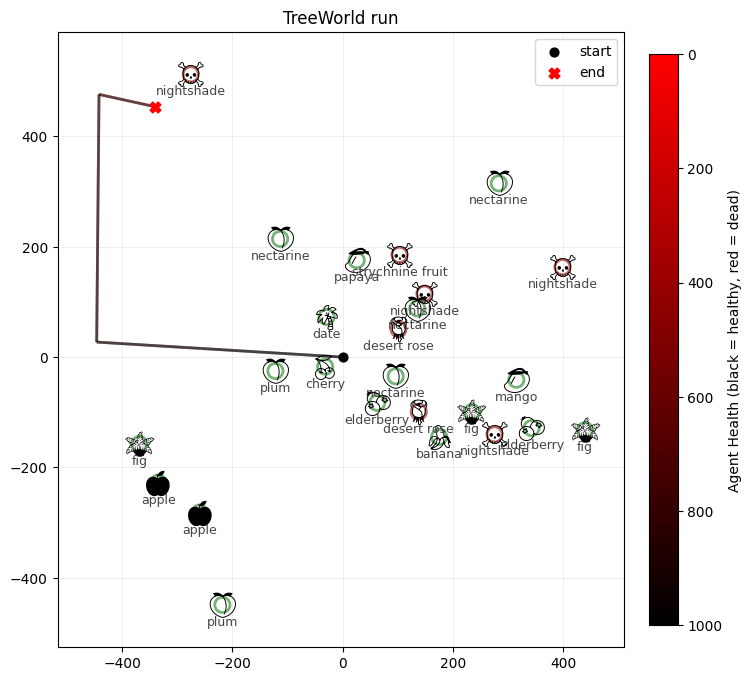

In [54]:
from tree_world.visualize import visualize_treeworld_run
visualize_treeworld_run(
    world.tree_locations.numpy().tolist(),
    [tree.name for tree in world.trees],
    [tree.is_poisonous for tree in world.trees],
    world.record_positions,
    world.record_healths,
    world.config.max_health,
    title="TreeWorld run",
    save_path="tree_world_run.png",
    show=False,
)

So our agent explores, but then when it gets hungry returns to a point near fruit. But it is unable to exploit the fruit, either because its sensors aren't good enough to determine where the trees are, or because it can't set a target exactly on a fruit tree.

Also, our agent has no impetus to avoid poison trees either, so sometimes it just eats poison.

Let's try to fix these issues by adding a local map of the environment.

## Adding a Local Approach / Avoid Map

The memory can tell the agent about its surroundings. In addition to the target, which is determined by overall drives, we can shape the agent's path to exploit the area around it as it goes, and to avoid problem locations.

First, let's make a function to build a map from the local environment and assess it for approach / avoid valence.

In [55]:
def build_local_map(
    memory: SpatialMemory, 
    location: Location, 
    num_grid_points: int=10, 
    grid_size: float=10.0,
    match_threshold: float=25.0,
):
    grid_extent = grid_size * num_grid_points
    grid_points = torch.linspace(-grid_extent, grid_extent, num_grid_points)
    grid_locations = (
        location.location.view(1, 1, 2) 
        + torch.cartesian_prod(grid_points, grid_points).view(1, -1, 2)
    )
    grid_locations_sd = torch.ones_like(grid_locations) * grid_size / 2

    memory_values = memory.read(grid_locations, grid_locations_sd, match_threshold=match_threshold).squeeze(0)
    grid_valence = drive_manager.assess_valence(memory_values)

    return grid_locations, grid_valence

valence max:  tensor(0.9985, grad_fn=<MaxBackward1>)
valence min:  tensor(0.0015, grad_fn=<MinBackward1>)


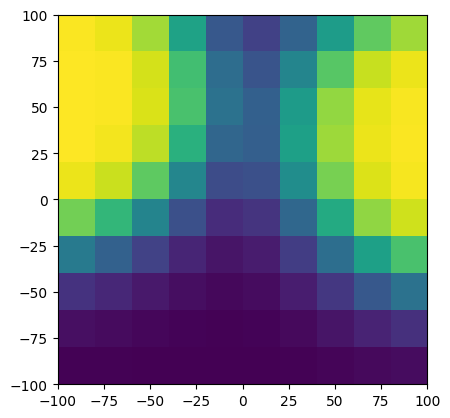

In [56]:
grid_extent = 100.0

locs, valence = build_local_map(memory, Location(torch.tensor([-250.0, -100.0]), torch.ones(2) * 5.0), num_grid_points=10, grid_size=10.0)

print("valence max: ", valence.max())
print("valence min: ", valence.min())

from matplotlib import pyplot as plt

plt.imshow(
    valence.view(10, 10).detach().cpu().numpy(),
    origin="lower",
    extent=[-grid_extent, grid_extent, -grid_extent, grid_extent],
)


This map is good, but we want our agent to only move forward, not backward, so rather than making a full local map, let's make a map of what is in front of the agent. We'll imagine our agent at the origin pointing in the anticipated direction of travel. Then, we'll make a grid that points out at $45^\circ$ angle on either side.

To do this, we'll make a grid of $G$ points $G_{i,j} = (i, j)$. We'll associate $G_{i,i}$ with the forward direction of motion, and then we will express each $G_{i,j}$ as a linear combination the unit vector $\left(\frac{\sqrt{2}}{2}, \frac{\sqrt{2}}{2}\right)$ (forward) and its orthonormal vector $\left(-\frac{\sqrt{2}}{2}, \frac{\sqrt{2}}{2}\right)$ (left). This is 
$$
\left[\begin{array}{c} x \\ y \end{array}\right] \,\,=\,\,
\left[\begin{array}{c} 
    \frac{\sqrt{2}}{2} & \frac{\sqrt{2}}{2} \\
    -\frac{\sqrt{2}}{2} & \frac{\sqrt{2}}{2}
\end{array}\right]\,\,
\left[\begin{array}{c} i \\ j\end{array}\right] \,\,=\,\,
\frac{\sqrt{2}}{2}\left[\begin{array}{c} i + j \\ j - i\end{array}\right]
$$
which is of course a $45^\circ$ rotation. This yields a grid of forward coordinates in the basis consisting of the direction of movement and its orthonormal complement with the agent at the origin. We can then finalize the coordinates for the local map in the real system by rotating to the real frame from the agent's self frame and translating from the agent's position to the absolute origin.

We can then add this grid to the 

In [57]:
import math

def build_forward_local_map(
    memory: SpatialMemory,
    location: Location,
    heading: torch.Tensor,
    num_grid_points: int=10,
    grid_size: float=10.0,
    match_threshold: float=25.0,
):
    axis_points = torch.arange(num_grid_points, dtype=heading.dtype, device=heading.device)
    axis_grid = torch.cartesian_prod(axis_points, axis_points)

    # we want to get the vector to the diagonal of the grid, which is y=x
    rotation_matrix = math.sqrt(0.5) * torch.tensor([
        [1, 1],
        [-1, 1],
    ], dtype=heading.dtype, device=heading.device)

    grid_points_relative = (axis_grid @ rotation_matrix.T) * grid_size

    heading_normalized = heading / torch.norm(heading)
    heading_orthogonal = torch.tensor([-heading_normalized[1].item(), heading_normalized[0].item()], 
                                      dtype=heading.dtype, device=heading.device)[None, :]

    grid_points_absolute = location.location[None, None, :] + (
        grid_points_relative[..., 0, None] * heading_normalized + grid_points_relative[..., 1, None] * heading_orthogonal
    )[None, ...]

    grid_locations_sd = torch.ones_like(grid_points_absolute) * grid_size / 2

    memory_values = memory.read(grid_points_absolute, grid_locations_sd, match_threshold=match_threshold).squeeze(0)
    grid_valence = drive_manager.assess_valence(memory_values)

    deviations = grid_points_relative[..., 1] 

    return grid_points_absolute, grid_valence, deviations, heading_orthogonal
    

valence max:  tensor(0.8871, grad_fn=<MaxBackward1>)
valence min:  tensor(0.0030, grad_fn=<MinBackward1>)


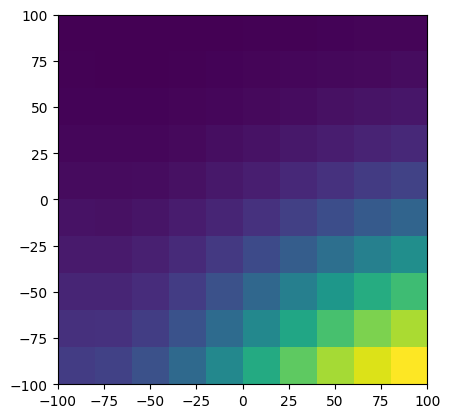

In [58]:
grid_extent = 100.0

agent_location_mean = torch.tensor([-250.0, -100.0])
agent_location_sd = torch.ones(2) * 5.0
agent_location = Location(agent_location_mean, agent_location_sd)
agent_heading = torch.tensor([-1.0, -1.0])

locs, valence, _, _ = build_forward_local_map(
    memory, agent_location, agent_heading, num_grid_points=10, grid_size=10.0
)

print("valence max: ", valence.max())
print("valence min: ", valence.min())

from matplotlib import pyplot as plt

plt.imshow(
    valence.view(10, 10).detach().cpu().numpy(),
    origin="lower",
    extent=[-grid_extent, grid_extent, -grid_extent, grid_extent],
)


## Local Force Control for Approach / Avoid Valence

The value `deviation` returned by this new method is a vector pointing orthogonally from the central forward line towards the position read from the map. This represents a "push" from the current heading that will cause it to deviate towards the point in question.

The valence tell us whether to push away or towards. In the case of a negative valence, we want to push harder if the negative stimulus is closer, and for a positive valence we push harder if it is further away.

From this, we can take the desired heading and deviate based on this local valence to avoid poison and approach edible fruit.



In [ ]:
def apply_deviation(
    location: Location, heading: torch.Tensor, memory: SpatialMemory, 
    deviation_strength: float=1.0,
    num_grid_points: int=10, grid_size: float=10.0, match_threshold: float=25.0
):
    locs, valence, deviations, heading_orthogonal = build_forward_local_map(
        memory, location, heading, num_grid_points, grid_size, match_threshold
    )

    grid_extent = grid_size * num_grid_points
    max_deviation_norm = grid_extent * math.sqrt(0.5)

    # deviation is the scalar magnitude and direction of the deviation vector
    # positive or negative depending on whether the point is to the left or right of the heading

    # for negative valence, we want to push away HARDER if the point is closer to our line of travel
    # whereas for positive valence, we want to push towards HARDER if the point is further away from our line of travel
    # we also want to choose the sign of the response based on the valence sign, so that we push away from poison and towards edible fruit
    negative_deviations = -(max_deviation_norm - deviations.abs()) * torch.sign(deviations)

    delta_delta = deviation_strength * torch.where(valence < 0.0, negative_deviations, deviations) * valence.abs()

    raw_heading = heading + delta_delta.mean() * heading_orthogonal
    heading_norm = torch.norm(heading)
    return heading_norm * raw_heading / torch.norm(raw_heading)


In [60]:
altered_heading = apply_deviation(
    agent_location, agent_heading, memory, num_grid_points=10, grid_size=10.0, match_threshold=25.0
)

print("original heading: ", agent_heading)
print("altered heading: ", altered_heading)


original heading:  tensor([-1., -1.])
altered heading:  tensor([[ 0.7033, -1.2269]], grad_fn=<DivBackward0>)


Now we can make a new agent model that use this local map to direct itself.

In [61]:
class DriveBasedAgentWithMemoryAndLocalMap(DriveBasedAgentWithMemory):
    deviation_strength: float = 5.0
    def adjust_heading(self, heading: torch.Tensor, agent_location: Location):
        return apply_deviation(
            agent_location, heading, self.memory, deviation_strength=self.deviation_strength,
            num_grid_points=5, grid_size=5.0, match_threshold=25.0
        ).detach().squeeze()

config.model_type = "DriveBasedAgentWithMemoryAndLocalMap"

In [62]:
world = TreeWorld.random_from_config(config)
steps = 1000

print(f"Running tree world for {steps} steps...")
world.run(steps, record=True)
print()
print("Tree world run complete.")

print(f"Agent health: {world.agent.health}")
print(f"Agent fruit eaten: {world.agent.fruit_eaten}")
print(f"Agent poisonous fruit eaten: {world.agent.poisonous_fruit_eaten}")
print(f"Agent total movement: {world.agent.total_movement}")
print(f"Agent final location: {torch.norm(world.agent.location).item()}")

Drive Embedding Classifier Loss (with fruit amount): 0.306037038564682 MSE: 1.2816405615012627e-05 Accuracy: 100.00%
Running tree world for 1000 steps...

Tree world run complete.
Agent health: 817.5888671875
Agent fruit eaten: 20
Agent poisonous fruit eaten: 0
Agent total movement: 1000.0
Agent final location: 197.92108154296875


/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)
/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'TreeWorld run'}>)

/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)


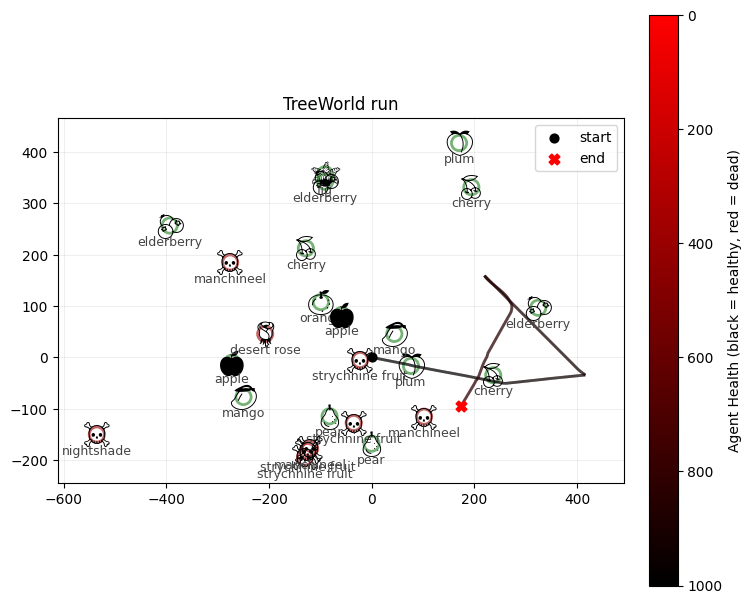

In [63]:
from tree_world.visualize import visualize_treeworld_run
visualize_treeworld_run(
    world.tree_locations.numpy().tolist(),
    [tree.name for tree in world.trees],
    [tree.is_poisonous for tree in world.trees],
    world.record_positions,
    world.record_healths,
    world.config.max_health,
    title="TreeWorld run",
    save_path="tree_world_run.png",
    show=False,
)

This time, the agent often manages to survive for all $1000$ steps.

Let's run it a bit longer.

In [66]:
world = TreeWorld.random_from_config(config)
steps = 50000

print(f"Running tree world for {steps} steps...")
world.run(steps, record=True)
print()
print("Tree world run complete.")

print(f"Agent health: {world.agent.health}")
print(f"Agent fruit eaten: {world.agent.fruit_eaten}")
print(f"Agent poisonous fruit eaten: {world.agent.poisonous_fruit_eaten}")
print(f"Agent total movement: {world.agent.total_movement}")
print(f"Agent final location: {torch.norm(world.agent.location).item()}")

Drive Embedding Classifier Loss (with fruit amount): 0.30593597888946533 MSE: 1.1985432138317265e-05 Accuracy: 100.00%
Running tree world for 50000 steps...

Tree world run complete.
Agent health: -0.050269946455955505
Agent fruit eaten: 25
Agent poisonous fruit eaten: 0
Agent total movement: 5746.0
Agent final location: 377.7901306152344


/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)
/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'TreeWorld run'}>)

/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)


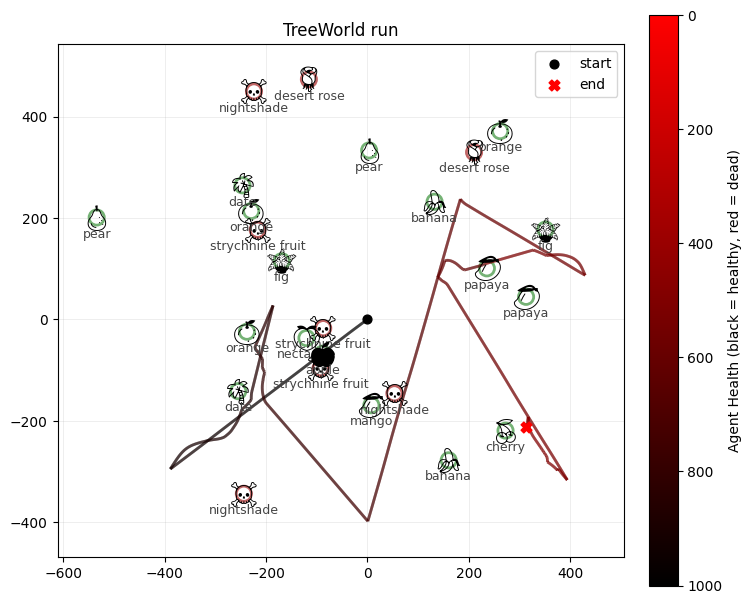

In [67]:
from tree_world.visualize import visualize_treeworld_run
visualize_treeworld_run(
    world.tree_locations.numpy().tolist(),
    [tree.name for tree in world.trees],
    [tree.is_poisonous for tree in world.trees],
    world.record_positions,
    world.record_healths,
    world.config.max_health,
    title="TreeWorld run",
    save_path="tree_world_run.png",
    show=False,
)

# Conclusion

We built a deterministic drive-based agent based on a memory map and a local approach/avoid controller.

The agent now does a decent job of exploring the space and surviving, but it still has some problems:
- It cannot "see" poisonous fruit fast enough, and sometimes stumbles onto poison before it can determine it is there to avoid it
- The local map is ambiguous in some cases; if there is a cluster of fruit trees, the deviation force may take the controller between two fruit trees, causing it to get no fruit
- In the force control, poison and edible fruit can cancel each other out, meaning that opportunities to exploit are lost.

The deficiencies, in part, are due to the way the "smell" sensor averages stimuli; it can be difficult to tease apart the meaning. We now have two options to improve:
1. Make the sensor better, so that the agent can better tell what to avoid and what to approach exactly
2. Make the deviation controller better, by training a network to decide when and where to deviate

We'll start by making a better neural controller, to see how far we can get before we have to improve the sensors.